#  Exploratory Data Analysis

In this notebook, we explore rainfall patterns across India to realise trends, variability, and regional differences.

The goal is to move beyond raw data and develop an intuitive understanding of:
- Long-term rainfall trends
- Seasonal contributions
- Regional disparities
- Distribution characteristics

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/cleaned_rainfall.csv"
df = pd.read_csv(file_path)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,region,year,jan,feb,mar,apr,may,jun,jul,aug,...,annual,jan-feb,mar-may,jun-sep,oct-dec,winter,summer,monsoon,post_monsoon,annual_calc
0,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,...,3373.2,136.3,560.3,1696.3,980.3,136.3,560.3,1696.3,980.3,3373.2
1,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,...,3520.7,159.8,458.3,2185.9,716.7,159.8,458.3,2185.9,716.7,3520.7
2,ANDAMAN & NICOBAR ISLANDS,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,...,2957.4,156.7,236.1,1874.0,690.6,156.7,236.1,1874.0,690.6,2957.4
3,ANDAMAN & NICOBAR ISLANDS,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,...,3079.6,24.1,506.9,1977.6,571.0,24.1,506.9,1977.6,571.0,3079.6
4,ANDAMAN & NICOBAR ISLANDS,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,...,2566.7,1.3,309.7,1624.9,630.8,1.3,309.7,1624.9,630.8,2566.7


In [ ]:
yearly = df.groupby('year')['annual'].mean().reset_index()

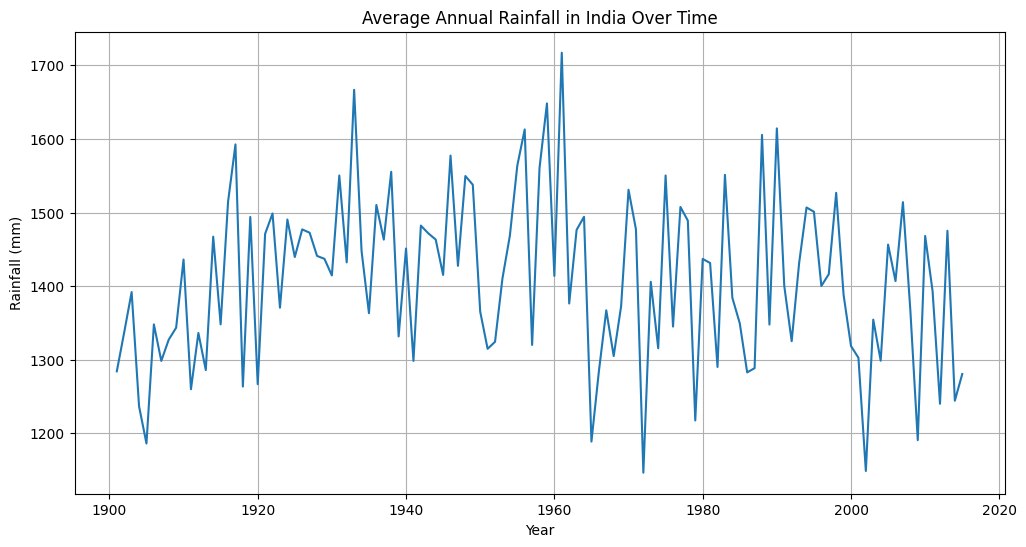

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(yearly['year'], yearly['annual'])
plt.title("Average Annual Rainfall in India Over Time")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.grid()
plt.show()

### Rainfall Trend Over Time

We analyze how average annual rainfall has changed over the years.

A regression line and rolling average are included to highlight long-term patterns and reduce short-term fluctuations.

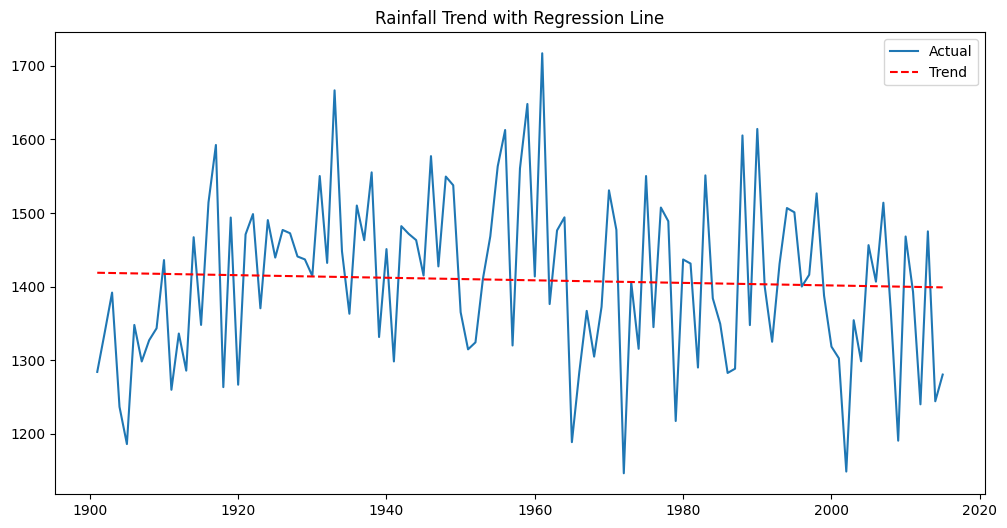

In [ ]:
z = np.polyfit(yearly['year'], yearly['annual'], 1)
p = np.poly1d(z)

plt.figure(figsize=(12,6))
plt.plot(yearly['year'], yearly['annual'], label='Actual')
plt.plot(yearly['year'], p(yearly['year']), "r--", label='Trend')

plt.legend()
plt.title("Rainfall Trend with Regression Line")
plt.show()

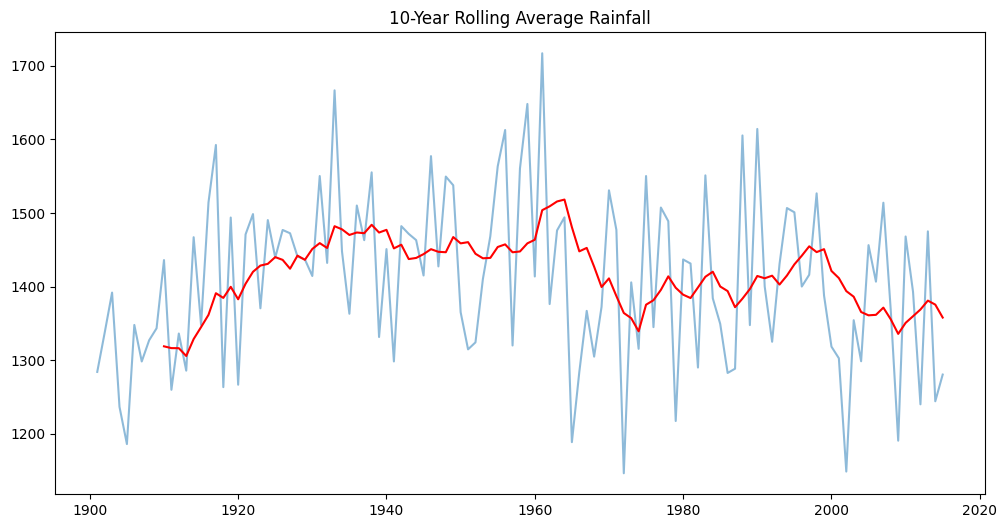

In [ ]:
yearly['rolling_mean'] = yearly['annual'].rolling(window=10).mean()

plt.figure(figsize=(12,6))
plt.plot(yearly['year'], yearly['annual'], alpha=0.5)
plt.plot(yearly['year'], yearly['rolling_mean'], color='red')

plt.title("10-Year Rolling Average Rainfall")
plt.show()

### Seasonal Contribution

Rainfall in India is highly seasonal.  
This section examines how different seasons contribute to the total annual rainfall.

Understanding this helps quantify India's dependence on monsoon rainfall.

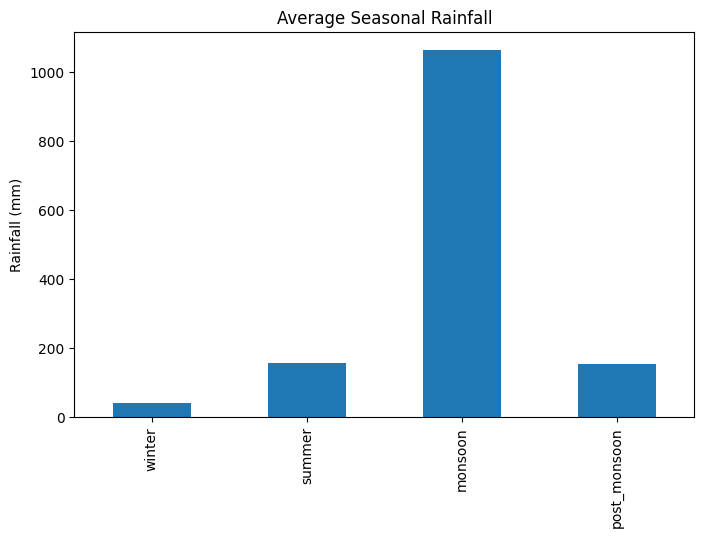

In [ ]:
seasonal = df[['winter','summer','monsoon','post_monsoon']].mean()
seasonal.plot(kind='bar', figsize=(8,5), title="Average Seasonal Rainfall")
plt.ylabel("Rainfall (mm)")
plt.show()

In [ ]:
df['monsoon_ratio'] = df['monsoon'] / df['annual']

print("Average monsoon contribution:", df['monsoon_ratio'].mean())

Average monsoon contribution: 0.768328456174495


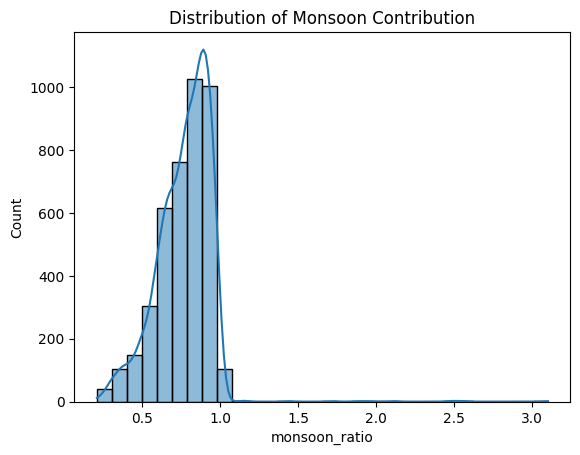

In [ ]:
sns.histplot(df['monsoon_ratio'], bins=30, kde=True)
plt.title("Distribution of Monsoon Contribution")
plt.show()

### Regional Comparison

Rainfall patterns vary significantly across regions.

This section compares:
- Average rainfall across regions
- Variability (uncertainty) in rainfall

Regions with high variability may face greater climate risk.

In [ ]:
region_avg = df.groupby('region')['annual'].mean().sort_values()

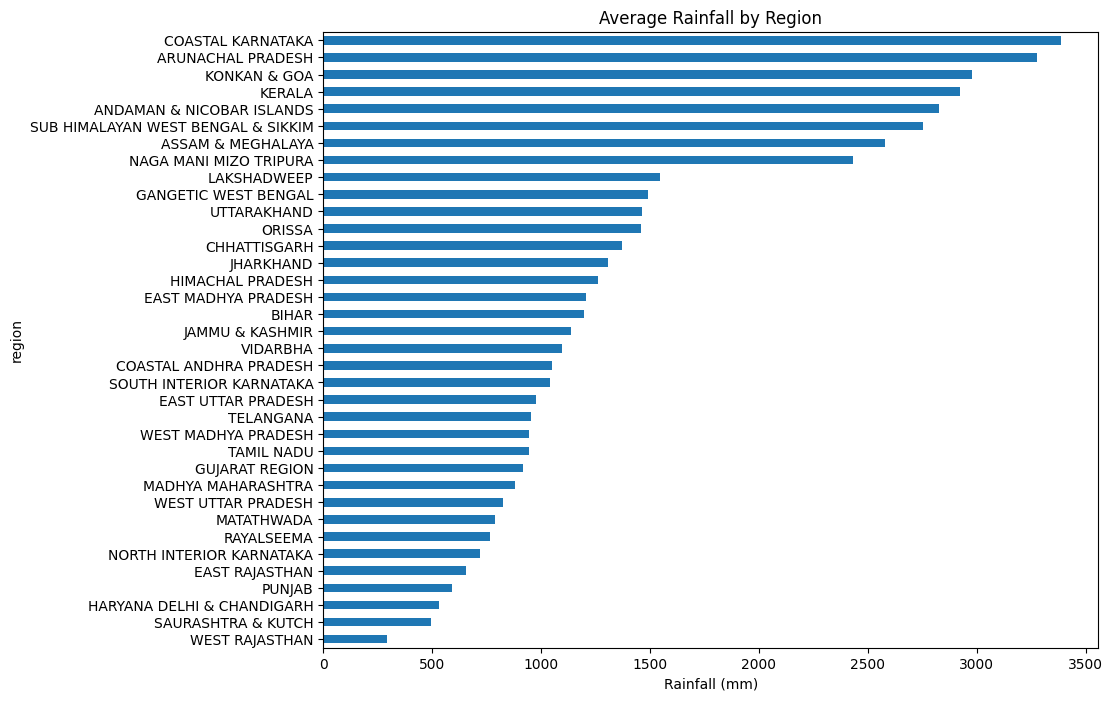

In [ ]:
plt.figure(figsize=(10,8))
region_avg.plot(kind='barh')
plt.title("Average Rainfall by Region")
plt.xlabel("Rainfall (mm)")
plt.show()

In [ ]:
region_var = df.groupby('region')['annual'].std().sort_values()

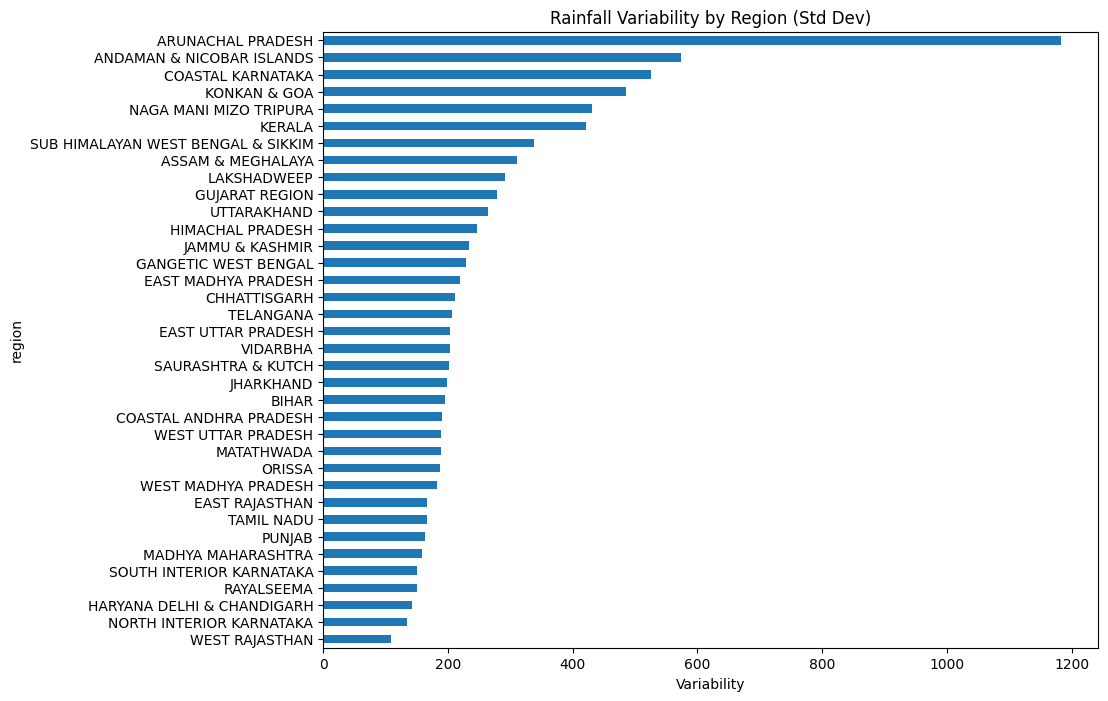

In [ ]:
plt.figure(figsize=(10,8))
region_var.plot(kind='barh')
plt.title("Rainfall Variability by Region (Std Dev)")
plt.xlabel("Variability")
plt.show()

In [ ]:
region_var.sort_values(ascending=False).head(5)

,annual
region,
ARUNACHAL PRADESH,1183.490399
ANDAMAN & NICOBAR ISLANDS,573.301222
COASTAL KARNATAKA,525.726583
KONKAN & GOA,485.095477
NAGA MANI MIZO TRIPURA,431.734909


### Distribution of Rainfall

We examine the distribution of annual rainfall to understand its statistical properties.

The presence of skewness indicates that extreme rainfall events may play a significant role.

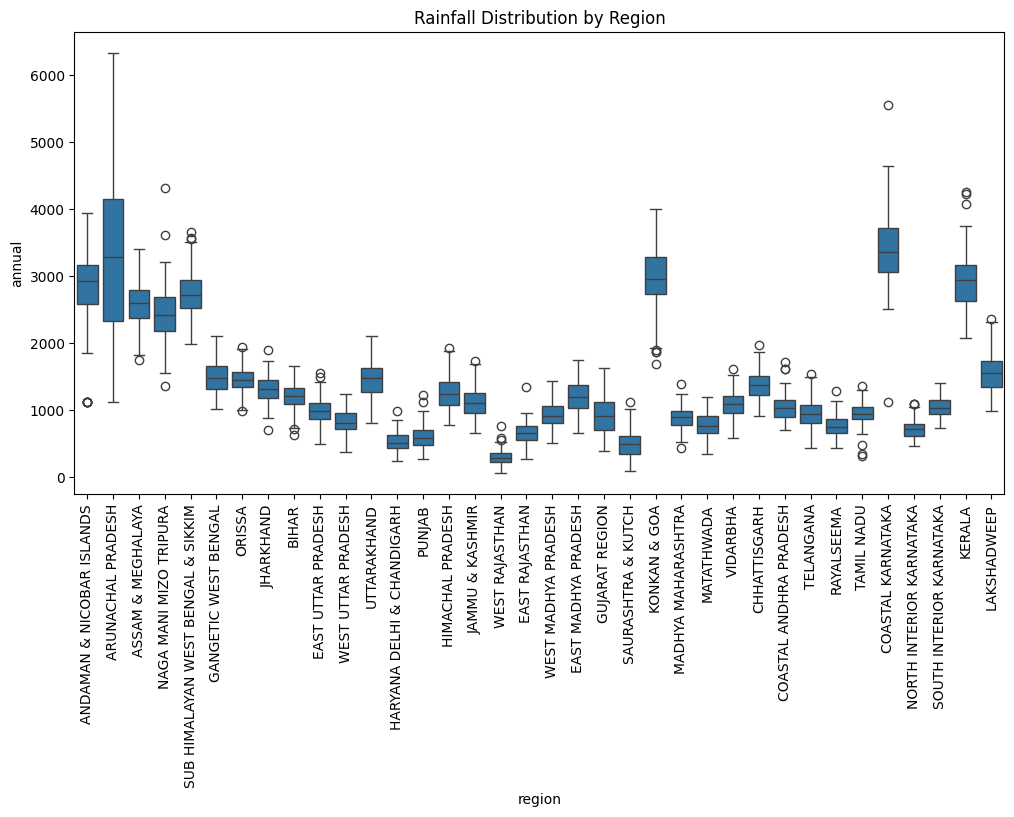

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='region', y='annual', data=df)
plt.xticks(rotation=90)
plt.title("Rainfall Distribution by Region")
plt.show()

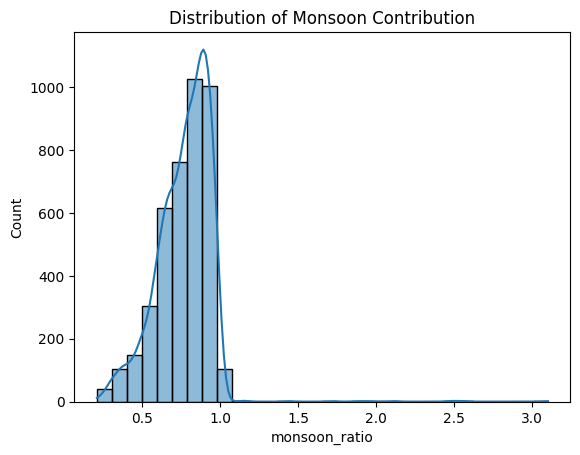

In [ ]:
sns.histplot(df['monsoon_ratio'], bins=30, kde=True)
plt.title("Distribution of Monsoon Contribution")
plt.show()

In [ ]:
extreme_years = yearly.sort_values(by='annual', ascending=False).head(10)
extreme_years

,year,annual,rolling_mean
60,1961,1717.100000,1503.962460
32,1933,1666.750000,1482.157500
58,1959,1648.230556,1458.884127
89,1990,1614.294444,1414.541111
55,1956,1612.840000,1457.476071
87,1988,1605.469444,1383.777500
16,1917,1592.533333,1391.133296
45,1946,1577.372222,1450.949246
54,1955,1563.554286,1453.929294
57,1958,1560.669444,1447.839127


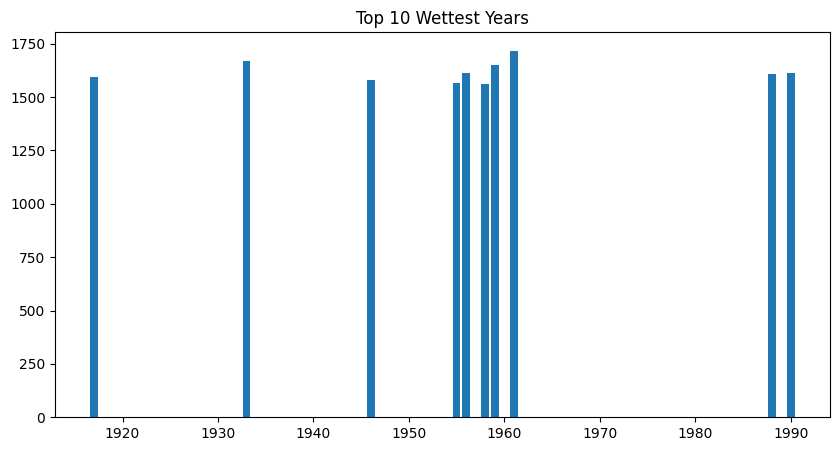

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(extreme_years['year'], extreme_years['annual'])
plt.title("Top 10 Wettest Years")
plt.show()

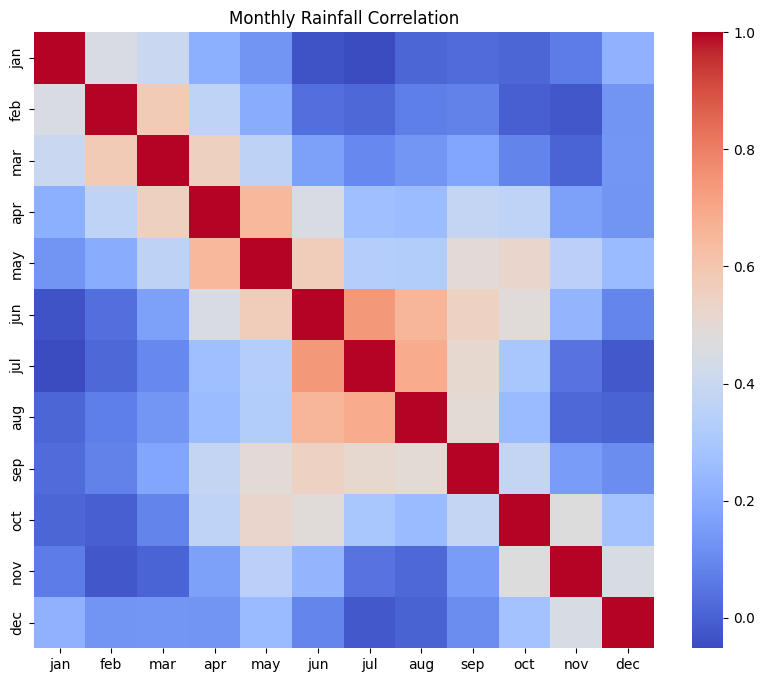

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df[['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']].corr(), cmap='coolwarm')
plt.title("Monthly Rainfall Correlation")
plt.show()

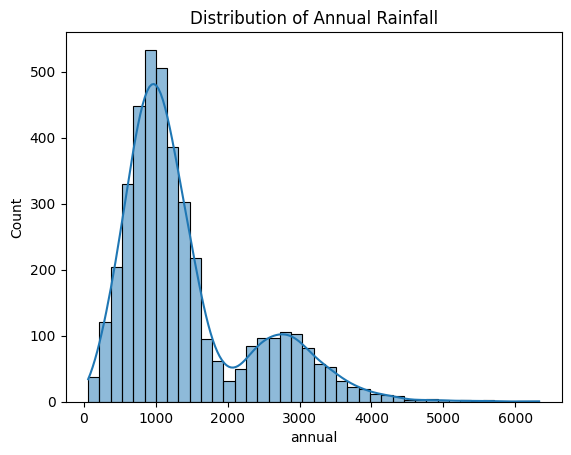

In [ ]:
sns.histplot(df['annual'], bins=40, kde=True)
plt.title("Distribution of Annual Rainfall")
plt.show()

In [ ]:
print("Skewness of annual rainfall:", df['annual'].skew())

Skewness of annual rainfall: 1.328302592152183


### Key Observations

- Rainfall exhibits significant year-to-year variability
- Monsoon dominates annual rainfall contribution
- Certain regions show higher uncertainty
- The distribution suggests the presence of extreme events
